<Axes: xlabel='x', ylabel='y'>

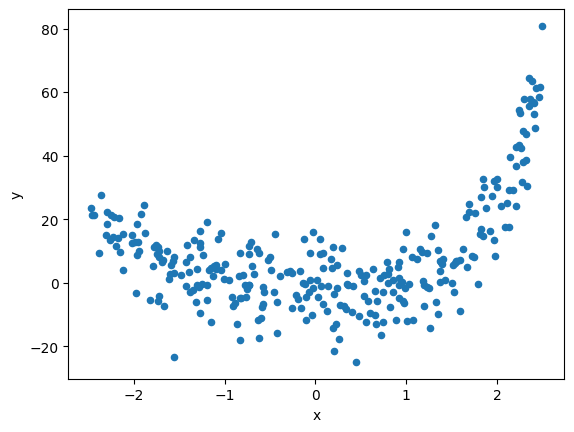

In [1]:
import numpy as np
import pandas as pd
size = 300
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x' : X, 'y' : y})
df.to_csv('dane_do_regresji.csv', index=None)
df.plot.scatter(x='x', y='y')

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

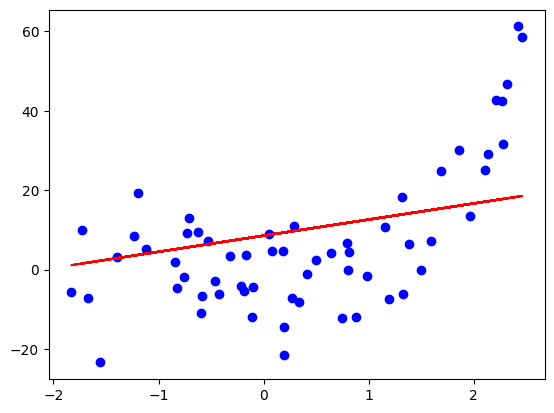

In [3]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

plt.clf()
plt.scatter(X_test, y_test, c="blue")
plt.plot(X_test, lin_reg.predict(X_test), c="red")

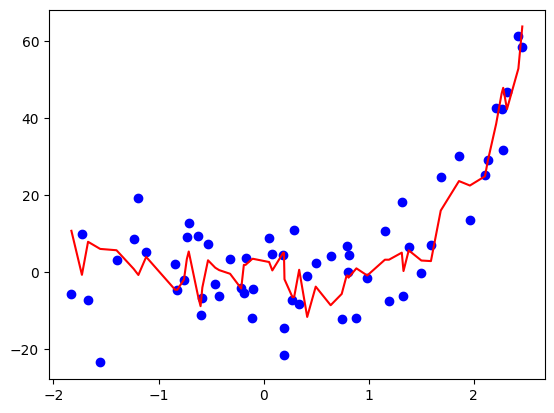

In [4]:
import sklearn.neighbors

knn_reg_3 = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)
knn_reg_3.fit(X_train, y_train)

plt.clf()
plt.scatter(X_test, y_test, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], knn_reg_3.predict(X_test)[sort_index], c="red")

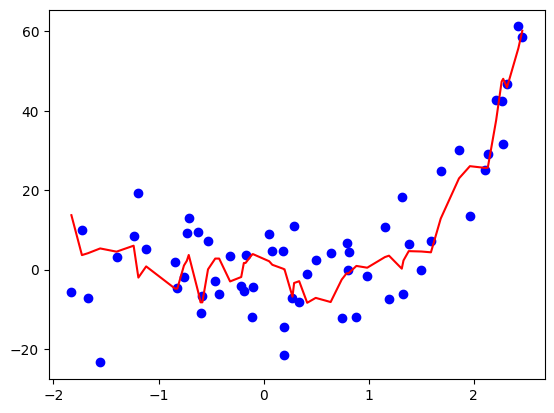

In [5]:
knn_reg_5 = sklearn.neighbors.KNeighborsRegressor(n_neighbors=5)
knn_reg_5.fit(X_train, y_train)

plt.clf()
plt.scatter(X_test, y_test, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], knn_reg_5.predict(X_test)[sort_index], c="red")

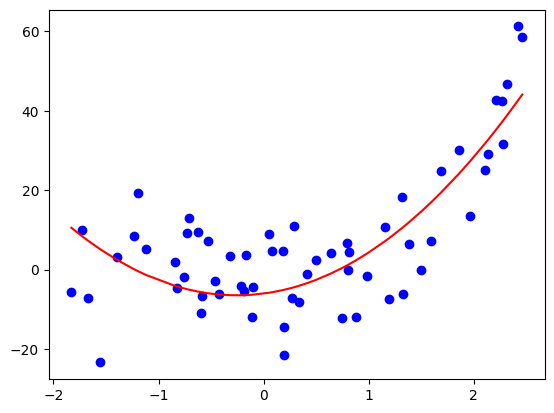

In [6]:
from sklearn.preprocessing import PolynomialFeatures

poly_features_2 = PolynomialFeatures(degree=2,include_bias=False)
X_poly_2 = poly_features_2.fit_transform(X_train)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly_2, y_train)

X_poly_test_2 = poly_features_2.transform(X_test)
plt.clf()
plt.scatter(X_test, y_test, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], lin_reg_2.predict(X_poly_test_2)[sort_index], c="red")

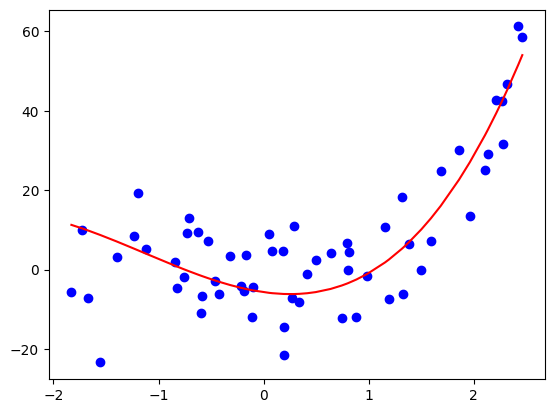

In [7]:
poly_features_3 = PolynomialFeatures(degree=3,include_bias=False)
X_poly_3 = poly_features_3.fit_transform(X_train)
lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_poly_3, y_train)

X_poly_test_3 = poly_features_3.transform(X_test)
plt.clf()
plt.scatter(X_test, y_test, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], lin_reg_3.predict(X_poly_test_3)[sort_index], c="red")

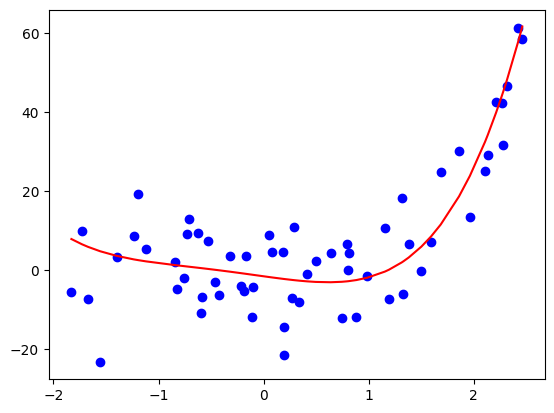

In [8]:
poly_features_4 = PolynomialFeatures(degree=4,include_bias=False)
X_poly_4 = poly_features_4.fit_transform(X_train)
lin_reg_4 = LinearRegression()
lin_reg_4.fit(X_poly_4, y_train)

X_poly_test_4 = poly_features_4.transform(X_test)
plt.clf()
plt.scatter(X_test, y_test, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], lin_reg_4.predict(X_poly_test_4)[sort_index], c="red")

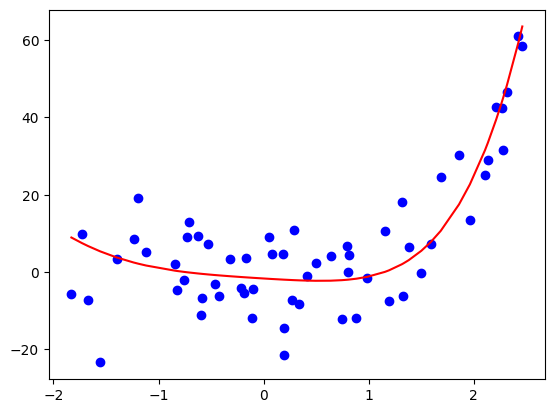

In [9]:
poly_features_5 = PolynomialFeatures(degree=5,include_bias=False)
X_poly_5 = poly_features_5.fit_transform(X_train)
lin_reg_5 = LinearRegression()
lin_reg_5.fit(X_poly_5, y_train)

X_poly_test_5 = poly_features_5.transform(X_test)
plt.clf()
plt.scatter(X_test, y_test, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], lin_reg_5.predict(X_poly_test_5)[sort_index], c="red")

In [10]:
from sklearn.metrics import mean_squared_error

mse_train_lin = mean_squared_error(y_train, lin_reg.predict(X_train))
mse_test_lin = mean_squared_error(y_test, lin_reg.predict(X_test))

mse_train_knn3 = mean_squared_error(y_train, knn_reg_3.predict(X_train))
mse_test_knn3 = mean_squared_error(y_test, knn_reg_3.predict(X_test))

mse_train_knn5 = mean_squared_error(y_train, knn_reg_5.predict(X_train))
mse_test_knn5 = mean_squared_error(y_test, knn_reg_5.predict(X_test))

mse_train_poly2 = mean_squared_error(y_train, lin_reg_2.predict(X_poly_2))
mse_test_poly2 = mean_squared_error(y_test, lin_reg_2.predict(X_poly_test_2))

mse_train_poly3 = mean_squared_error(y_train, lin_reg_3.predict(X_poly_3))
mse_test_poly3 = mean_squared_error(y_test, lin_reg_3.predict(X_poly_test_3))

mse_train_poly4 = mean_squared_error(y_train, lin_reg_4.predict(X_poly_4))
mse_test_poly4 = mean_squared_error(y_test, lin_reg_4.predict(X_poly_test_4))

mse_train_poly5 = mean_squared_error(y_train, lin_reg_5.predict(X_poly_5))
mse_test_poly5 = mean_squared_error(y_test, lin_reg_5.predict(X_poly_test_5))

mse_data = {
    'train_mse': [mse_train_lin, mse_train_knn3, mse_train_knn5, mse_train_poly2, mse_train_poly3, mse_train_poly4, mse_train_poly5],
    'test_mse': [mse_test_lin, mse_test_knn3, mse_test_knn5, mse_test_poly2, mse_test_poly3, mse_test_poly4, mse_test_poly5]
}

index_labels = ['lin_reg', 'knn_3_reg', 'knn_5_reg', 'poly_2_reg', 'poly_3_reg', 'poly_4_reg', 'poly_5_reg']

df_mse = pd.DataFrame(mse_data, index=index_labels)

print(df_mse)

df_mse.to_pickle('mse.pkl')

             train_mse    test_mse
lin_reg     253.634489  238.867352
knn_3_reg    46.339264   93.532034
knn_5_reg    52.090702   96.535369
poly_2_reg   94.648147  108.963565
poly_3_reg   73.217580   91.658733
poly_4_reg   62.107761   81.995735
poly_5_reg   61.484717   83.785899


In [11]:
import pickle

regressors_list = [
    (lin_reg, None), 
    (knn_reg_3, None), 
    (knn_reg_5, None), 
    (lin_reg_2, poly_features_2), 
    (lin_reg_3, poly_features_3), 
    (lin_reg_4, poly_features_4), 
    (lin_reg_5, poly_features_5)
]

with open('reg.pkl', 'wb') as f:
    pickle.dump(regressors_list, f)